# 📡 Workshop 5.2: Sensor Fusion & Spoofing Attacks in Autonomous Vehicles

## 🎯 Learning Objectives

Upon completion of this notebook, you will be able to:

1. **Explain why autonomous vehicles use multiple sensors** and how their data is fused
2. **Understand and implement sensor spoofing** as a Gaussian noise injection attack
3. **Apply early feature fusion** by concatenating multi-modal sensor feature vectors
4. **Train and compare Logistic Regression classifiers** on single-sensor vs. fused data
5. **Quantify the resilience gap** — how much fusion helps (or fails) under attack
6. **Critically evaluate** trade-offs between fusion benefit and spoofing vulnerability
7. **Propose adaptive fusion strategies** for real-world adversarial robustness

## 📚 Prerequisites

| Concept | Why It Matters Here |
|---|---|
| Python basics (functions, loops, NumPy arrays) | Data generation and manipulation |
| Pandas DataFrames | Dataset loading via OpenML |
| Binary classification concepts | Our task: class 1 vs. all others |
| Train/test split and data leakage | Correct evaluation methodology |
| Feature scaling (StandardScaler) | Preprocessing sensor readings |
| Logistic Regression | Our classification model |
| Gaussian (normal) distribution | How spoofing noise is modeled |

> 💡 **New to Logistic Regression?** It is a linear binary classifier that learns weights for each feature. Despite the word "regression", it outputs probabilities between 0 and 1 and is one of the most interpretable classifiers in machine learning.

## Part 1: Theoretical Background

### 1.1 Why Autonomous Vehicles Use Multiple Sensors

No single sensor can reliably perceive the environment under all conditions. Autonomous vehicles therefore deploy **sensor suites** — complementary sensors whose strengths compensate for each other's weaknesses:

| Sensor | Strengths | Weaknesses |
|---|---|---|
| **Camera** | Rich color, texture, object recognition | Fails in fog, rain, glare, darkness |
| **LiDAR** | Precise 3D geometry, works in darkness | Expensive, struggles with rain/snow, no color |
| **RADAR** | Works in all weather, detects velocity | Low resolution, can't classify objects reliably |
| **Ultrasound** | Short-range distance sensing, cheap | Slow update rate, limited range |
| **GPS/IMU** | Absolute positioning | GPS fails indoors/tunnels; IMU drifts |

By **fusing** these modalities, a vehicle can maintain reliable perception even when one sensor degrades.

---

### 1.2 Levels of Sensor Fusion

Sensor fusion can happen at different levels of the processing pipeline:

```

Early Fusion(this workshop)
  Camera features ─┐                                      
                   ├─ Concatenate → Classifier            
  LiDAR features  ─┘                                     
                                                         
Feature-level / Late Fusion
  Camera features → Model A ─┐
                             ├─ Combine scores → Decision  
  LiDAR features  → Model B ─┘                             

Decision-level Fusion
  Camera → Detections ─┐
                       ├─ Merge detections → Decision     
  LiDAR  → Detections ─┘                                   
```

In this workshop we implement **early fusion** (also called feature-level fusion): simply concatenating the feature vectors from both sensor modalities before training a single classifier.

---

### 1.3 Sensor Spoofing Attacks

**Sensor spoofing** is an attack where an adversary injects false or corrupted data into a sensor's feed. Unlike adversarial examples (which manipulate model inputs at inference), spoofing attacks target the **physical or signal layer** of the sensor pipeline.

| Attack Type | Sensor Targeted | Method |
|---|---|---|
| **LiDAR spoofing** | LiDAR | Laser pulses that create phantom obstacles or blind spots |
| **Camera spoofing** | Camera | Projecting adversarial patterns, glare attacks, IR blinding |
| **GPS spoofing** | GPS/GNSS | Broadcasting fake signals to shift perceived position |
| **RADAR spoofing** | RADAR | Jamming or replaying signals to create false velocity/range readings |
| **Ultrasound spoofing** | Ultrasound | Emitting interfering sound pulses |

In this experiment, spoofing is **modeled as additive Gaussian noise** of high amplitude:

$$x_{\text{spoofed}} = x_{\text{clean}} + \mathcal{N}(0,\ \sigma^2)$$

where `strength` controls σ. This is a simplification that captures the key effect: the corrupted sensor provides unreliable, noise-dominated readings that mislead the classifier.

---

### 1.4 The Core Research Question

This workshop answers: **"Does sensor fusion make an autonomous perception system more resilient to sensor spoofing attacks?"**

We test three classifiers under two conditions:

```
                  Normal          Camera Spoofed
                 ┌──────────────────────────────┐
 Camera-only     │  clean acc   │  spoofed acc  │
 LiDAR-only      │  clean acc   │  (N/A — not   │
 Fused System    │  clean acc   │  attacked)    │
                 │              │  spoofed acc  │
                 └──────────────────────────────┘
```

**Hypothesis:** The fused system should be *more* resilient than camera-only, because LiDAR data (untouched) partially compensates for the corrupted camera. But how much?

---

### 1.5 About Logistic Regression for This Task

Logistic Regression is the right tool here because:
- It is **interpretable**: we can inspect feature weights to see which sensors the model relies on
- It is **fast**: trains in milliseconds on this dataset — lets us focus on the fusion concept, not training time
- It serves as a **baseline**: if even a simple linear model shows fusion benefit, the result is convincing
- Its **linear decision boundary** is easy to reason about when sensors are corrupted


## Part 2: Hands-On

### Step 1: Import necessary libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

## Step 2: Dataset Exploration — Wall-Following Robot Navigation

### 2.1 About the Dataset

We use the **Wall-Following Robot Navigation** dataset (OpenML ID 1497), collected from a real SCITOS G5 robot navigating a room while following walls.

**Dataset characteristics:**

| Property | Value |
|---|---|
| Source | UCI / OpenML |
| Samples | 5,456 robot navigation records |
| Features | 24 ultrasound sensor readings (US1–US24), arranged around the robot |
| Target | Navigation action taken (4 classes) |
| Feature type | Continuous (distance readings in cm) |

**The 4 navigation classes:**

| Class | Meaning | Count |
|---|---|---|
| `1` | Move Forward | 2,205  |
| `2` | Slight Right Turn | 2,097 |
| `3` | Sharp Right Turn | 328 |
| `4` | Slight Left Turn | 826 |

### 2.2 Why This Dataset for Sensor Fusion Simulation?

Although this dataset comes from ultrasound sensors (not cameras and LiDAR), it provides a **realistic proxy** for sensor fusion research:
- 24 real sensor readings with genuine correlations and natural noise
- Sensors are spatially arranged around the robot — different sensors capture different aspects of the environment, just like camera vs. LiDAR
- We split them into two groups of 12 to simulate two distinct sensor modalities


### 2.3 What `fetch_openml()` Does

`fetch_openml(data_id=1497, as_frame=True, parser='auto')` automatically:
1. Downloads the dataset from [openml.org](https://openml.org) on first call (~caches locally after)
2. Returns an object with `.data` (feature DataFrame) and `.target` (label Series)
3. `as_frame=True` returns pandas DataFrames instead of NumPy arrays

In [ ]:
# Load the data
data = fetch_openml(data_id=1497, as_frame=True, parser='auto')
X = data.data.values
y = data.target

In [ ]:
# Convert to DataFrame for easier exploration
df = pd.DataFrame(X, columns=data.feature_names)
df["target"] = y.values

# Know the size of the dataset
print(f"Shape of the Normal dataset: {df.shape}")
print(f"Number of samples in the Normal dataset: {df.shape[0]}")
print(f"Number of features in the Normal dataset: {df.shape[1] - 1}")
print("\nFeature Statistics:")
print(df.describe())

Shape of the Normal dataset: (5456, 25)
Number of samples in the Normal dataset: 5456
Number of features in the Normal dataset: 24

Feature Statistics:
                V1           V2           V3           V4           V5  \
count  5456.000000  5456.000000  5456.000000  5456.000000  5456.000000   
mean      1.471617     2.327043     2.489347     2.796501     2.958552   
std       0.802801     1.410146     1.247435     1.309368     1.339225   
min       0.400000     0.437000     0.470000     0.833000     1.120000   
25%       0.921000     1.362000     1.538750     1.731000     1.774000   
50%       1.335000     1.904500     2.064000     2.458000     2.667000   
75%       1.814000     2.681500     2.739250     4.093500     4.314500   
max       5.000000     5.025000     5.029000     5.017000     5.000000   

                V6           V7           V8           V9          V10  ...  \
count  5456.000000  5456.000000  5456.000000  5456.000000  5456.000000  ...   
mean      2.893073     

In [ ]:
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V16,V17,V18,V19,V20,V21,V22,V23,V24,target
0,0.438,0.498,3.625,3.645,5.0,2.918,5.0,2.351,2.332,2.643,...,0.593,0.502,0.493,0.504,0.445,0.431,0.444,0.440,0.429,4
1,0.438,0.498,3.625,3.648,5.0,2.918,5.0,2.637,2.332,2.649,...,0.592,0.502,0.493,0.504,0.449,0.431,0.444,0.443,0.429,4
2,0.438,0.498,3.625,3.629,5.0,2.918,5.0,2.637,2.334,2.643,...,0.593,0.502,0.493,0.504,0.449,0.431,0.444,0.446,0.429,4
3,0.437,0.501,3.625,3.626,5.0,2.918,5.0,2.353,2.334,2.642,...,0.593,0.502,0.493,0.504,0.449,0.431,0.444,0.444,0.429,4
4,0.438,0.498,3.626,3.629,5.0,2.918,5.0,2.640,2.334,2.639,...,0.592,0.502,0.493,0.504,0.449,0.431,0.444,0.441,0.429,4


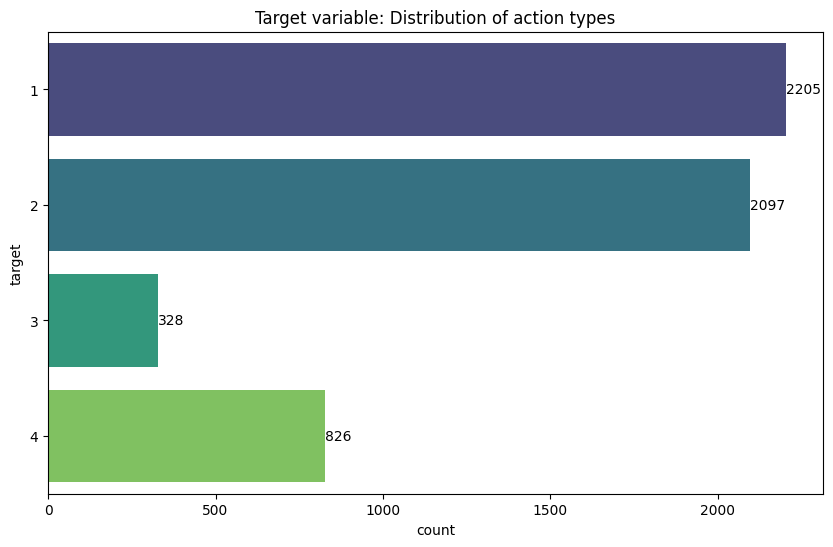

Class distribution:
1: 2205 (40.41%)
2: 2097 (38.43%)
4: 826 (15.14%)
3: 328 (6.01%)


In [ ]:
fl = df["target"]

plt.figure(figsize=(10,6))
ax = sns.countplot(y=fl, hue=fl, palette='viridis')
plt.title('Target variable: Distribution of action types')

for bar in ax.containers:
    ax.bar_label(bar)

labels = [label.get_text() for label in ax.get_yticklabels()]

ax.set_yticks(ax.get_yticks())
ax.set_yticklabels(labels)
plt.show()

print("Class distribution:")
value_counts = fl.value_counts()
value_percentages = fl.value_counts(normalize=True) * 100

for c_type in value_counts.index:
    print(f"{c_type}: {value_counts[c_type]} ({value_percentages[c_type]:.2f}%)")

### Step 3: Load and split the data

### 3.1 What `load_and_split_sensor_data()` Function Does

This function encapsulates the entire data preparation pipeline. It performs five distinct steps:

```
OpenML Dataset (24 sensors, 4 classes)
   ↓  Stratified 70/30 train/test split
   ↓  StandardScaler fit on train, transform both
   ↓  Split 24 sensors → 12 'Camera' + 12 'LiDAR'
   ↓  Return (cam_train, lidar_train, y_train), (cam_test, lidar_test, y_test)
```

---

### 3.2 Step-by-Step Breakdown

#### 3.2.1 Binary Relabeling

The original dataset has 4 navigation classes. We simplify to a **binary task**:  
- **Class 1** (`Move Forward`) → label `1`  
- **All other classes** (2, 3, 4) → label `0`  

This is a natural AV analogy: "Is the vehicle safe to move forward?" — yes or no.


#### 3.2.2 Virtual Sensor Split — Simulating Camera vs. LiDAR

The 24 scaled sensor readings are split into two groups of 12:
- **Sensors 0–11** → "Camera-like" features (conceptually: texture/visual features)
- **Sensors 12–23** → "LiDAR-like" features (conceptually: depth/range features)


This split is **spatially meaningful**: sensors 1–12 cover the front half of the robot, sensors 13–24 cover the rear half — different spatial perspectives, analogous to different sensor modalities.

In [ ]:
def load_and_split_sensor_data(random_seed=42):
    """
    Loads the Wall-Following Robot Navigation dataset.
    This dataset contains 24 ultrasound sensor readings.
    We will split these into two 'virtual' sensor suites:
    Suite A (Camera-like) and Suite B (LiDAR-like).
    """
    data = fetch_openml(data_id=1497, as_frame=True, parser='auto')
    X = data.data.values
    y = data.target

    unique_classes = y.unique()
    print(f"Detected classes in dataset: {list(unique_classes)}")
    print(f"Class distribution:\n{y.value_counts()}")

    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=random_seed, stratify=y
    )

    # Scaler fit
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Split 24 sensors into two groups (12 'Camera', 12 'LiDAR')
    cam_train, lidar_train = X_train_scaled[:, :12], X_train_scaled[:, 12:]
    cam_test,  lidar_test  = X_test_scaled[:, :12],  X_test_scaled[:, 12:]

    return (cam_train, lidar_train, y_train), (cam_test, lidar_test, y_test)

### Step 4: A Spoofing Attack

### 4.1 Attack Model

This function simulates a **noise injection attack** on sensor data. In real systems, such corruption can arise from:

- A **blinding attack** (bright laser or IR emitter overwhelming a camera sensor)
- **Signal jamming** (radio frequency interference on RADAR/GPS)
- **Replay attacks** (feeding old sensor recordings to the system)
- **Physical tampering** (covering or obstructing a sensor)


### 4.2 The `strength` Parameter

After StandardScaler, all features have **std ≈ 1**. The `strength` parameter therefore directly controls the **signal-to-noise ratio (SNR)**:

| `strength` | Effect on scaled features | SNR analogy |
|---|---|---|
| `0.1` | Barely perceptible noise (10% of std) | High quality sensor |
| `0.5` | Mild degradation | Sensor in adverse weather |
| `1.0` | Noise equals signal level (SNR ≈ 1) | Heavily degraded sensor |
| `2.0` | Noise dominates signal (SNR < 1) | Severely compromised sensor |
| `4.0` | Noise overwhelms signal (used in our experiment) | Sensor effectively useless |

### 4.3 Why Gaussian Noise?

Gaussian noise is the standard model for **uncorrelated, additive sensor noise** (thermal noise, quantization noise). While real spoofing attacks may produce structured noise, Gaussian noise is a simple, widely-used baseline that captures the key effect: **reducing the statistical separability** of the two classes in feature space.

> ⚠️ **Important:** We only spoof the **test** data, not the training data. The models are trained on clean data and then evaluated on compromised data — this simulates an **adversarial attack at inference time**, which is the realistic threat scenario.

In [ ]:
def spoof_sensor(sensor_feats, strength=2.0, random_seed=42):
    """
    Simulates a spoofing attack by injecting Gaussian noise
    into the real sensor readings.
    """
    rng = np.random.default_rng(random_seed)
    n, d = sensor_feats.shape
    noise = strength * np.random.randn(n, d)
    return sensor_feats + noise

### Step 5: Early Fusion Strategy


**Early fusion** (also called **feature-level fusion** or **data-level fusion**) is the simplest multi-modal integration strategy. It works by directly **concatenating the feature vectors** from all sensor modalities into a single, wider feature vector before training:

```
Camera features:  [c₁, c₂, ..., c₁₂]           shape: (n, 12)
LiDAR features:   [l₁, l₂, ..., l₁₂]            shape: (n, 12)
                          ↓ np.concatenate(..., axis=1)
Fused features:   [c₁, ..., c₁₂, l₁, ..., l₁₂] shape: (n, 24)
```

The fused classifier then learns **which features from either sensor** are most predictive — it can automatically down-weight corrupted sensors if their features are noisy.


In [ ]:
def fuse_features(cam, lidar):
    return np.concatenate([cam, lidar], axis=1)

### Step 6: Executing the Data Pipeline

Now we call `load_and_split_sensor_data()` to execute the full preprocessing pipeline and obtain our four sensor arrays:

| Variable | Shape | Description |
|---|---|---|
| `cam_train` | `(3819, 12)` | Camera features for training |
| `lidar_train` | `(3819, 12)` | LiDAR features for training |
| `y_train` | `(3819,)` | Binary labels for training |
| `cam_test` | `(1637, 12)` | Camera features for testing (clean) |
| `lidar_test` | `(1637, 12)` | LiDAR features for testing (clean) |
| `y_test` | `(1637,)` | Binary labels for testing |

In [ ]:
(cam_train, lidar_train, y_train), (cam_test, lidar_test, y_test) = load_and_split_sensor_data()

Detected classes in dataset: ['4', '2', '1', '3']
Class distribution:
Class
1    2205
2    2097
4     826
3     328
Name: count, dtype: int64


### Step 7: Training Three Classifiers on Clean Data

We train three separate Logistic Regression classifiers, each using different input features:

| Model | Input Features | Dimension | Purpose |
|---|---|---|---|
| `clf_cam` | Camera only | 12 | Baseline: single-sensor (camera) |
| `clf_lidar` | LiDAR only | 12 | Baseline: single-sensor (LiDAR) |
| `clf_fuse` | Camera + LiDAR | 24 | Experimental: early fusion |

All three are trained on **clean (unperturbed) training data**. This is the correct experimental design:
- Training simulates normal operation (before an attack is launched)
- The attack only affects test-time inference
- This tests whether the models, as trained, can withstand real-world adversarial conditions

In [ ]:
#  Train Models
print("\nTraining models on clean data...")
clf_cam = LogisticRegression(max_iter=1000).fit(cam_train, y_train)
clf_lidar = LogisticRegression(max_iter=1000).fit(lidar_train, y_train)
clf_fuse = LogisticRegression(max_iter=1000).fit(fuse_features(cam_train, lidar_train), y_train)


Training models on clean data...


### Step 8: Attack Simulation

### 8.1 Spoofing the Camera Sensor

We attack the **camera sensor** specifically. This choice reflects real-world threat models:
- Cameras are the most exposed sensor (visible light, easily accessible via physical proximity)
- Camera spoofing attacks (blinding, projection) are documented in adversarial ML research
- LiDAR spoofing typically requires laser hardware — more difficult and expensive to execute

By leaving LiDAR untouched, we create an ideal scenario for **fusion to demonstrate its benefit** — the fused model has access to the clean LiDAR signal even when camera is compromised.

### 8.2 Attack Strength: `strength=4.0`

With `strength=4.0` and features already scaled to std≈1, the injected noise has **4× the standard deviation of the original signal**. This represents a severe attack where the camera is essentially blinded — its readings provide almost no useful information.

We deliberately choose a severe attack to test the upper limit: can fusion still help when one sensor is almost completely useless?

### 8.3 What Remains Unchanged

| Data | Status |
|---|---|
| `cam_train`, `lidar_train`, `y_train` | ✅ Unchanged — models are already trained |
| `lidar_test` | ✅ Unchanged — LiDAR sensor not attacked |
| `y_test` | ✅ Unchanged — true labels are the ground truth |
| `cam_test` | ✅ Unchanged — original clean test data preserved |
| `cam_test_spoof` | ⚡ New — corrupted camera test data |

We keep both `cam_test` (clean) and `cam_test_spoof` (attacked) so we can compare **normal vs. spoofed conditions** for the same test samples.

In [ ]:
# Create Spoofed Data (Simulating a real-time attack on the Camera)
cam_test_spoof = spoof_sensor(cam_test, strength=4.0, random_seed=42)

In [ ]:
sensor_labels = [f"V{i+1}" for i in range(12)]

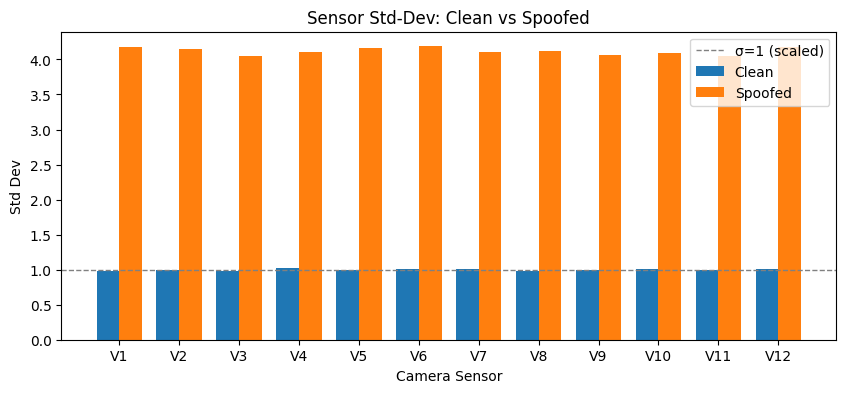

In [ ]:
# Std-Dev per Sensor: Clean vs Spoofed

fig, ax = plt.subplots(figsize=(10, 4))
x, w = np.arange(12), 0.38
ax.bar(x - w/2, cam_test.std(axis=0),       w, label="Clean")
ax.bar(x + w/2, cam_test_spoof.std(axis=0), w, label="Spoofed")
ax.axhline(1.0, color="gray", linestyle="--", linewidth=1, label="σ=1 (scaled)")
ax.set(xticks=x,
       xticklabels=sensor_labels,
       title="Sensor Std-Dev: Clean vs Spoofed",
       ylabel="Std Dev",
       xlabel="Camera Sensor")
ax.legend()
plt.show()

Here, we can see that spoofing inflated every camera sensor's standard deviation from ~1 to ~4. This means that the injected noise is 4 times larger than the original signal, which is exactly matching with `strength=4.0`.

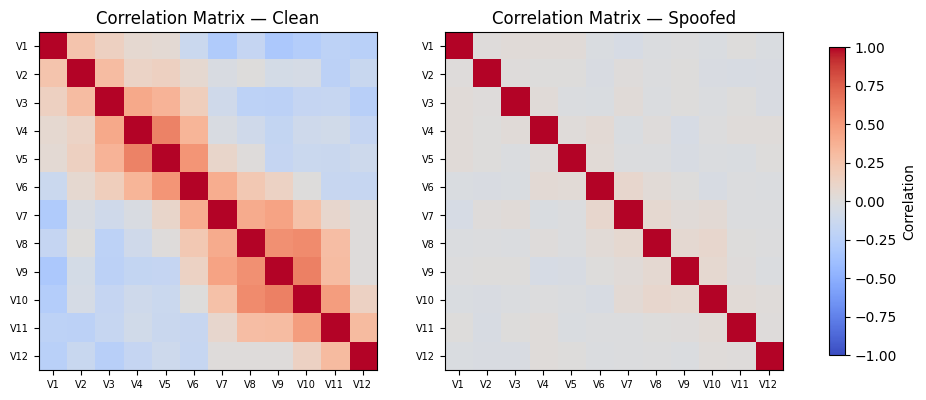

In [ ]:
# Correlation Matrix

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, data, title in zip(axes,
                            [cam_test, cam_test_spoof],
                            ["Correlation Matrix — Clean", "Correlation Matrix — Spoofed"]):
    im = ax.imshow(np.corrcoef(data.T), cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_xticks(range(12)); ax.set_yticks(range(12))
    ax.set_xticklabels(sensor_labels, fontsize=7)
    ax.set_yticklabels(sensor_labels, fontsize=7)
    ax.set_title(title)

plt.colorbar(im, ax=axes, label="Correlation", shrink=0.8)
plt.show()

The above plot clearly shows that spoofing destroys all inter-sensor correlations. The clean data shows meaningful relationships between sensors (warm-off diagonal regions), while the spoofed matrix collapses tp near-zero everywhere except the diagonal. This means that after spoofing each sensor behaves as independent random noise.

### Step 9: Evaluation — Measuring Resilience Under Attack

### 9.1 What We Are Measuring

We evaluate **five accuracy scores** across two conditions:

| Measurement | Classifier | Test Data | What It Tells Us |
|---|---|---|---|
| `acc_cam_norm` | Camera-only | Clean camera | Baseline camera performance |
| `acc_lidar_norm` | LiDAR-only | Clean LiDAR | LiDAR performance (attack-free reference) |
| `acc_fuse_norm` | Fused | Clean cam + clean LiDAR | Fusion benefit in normal conditions |
| `acc_cam_spoof` | Camera-only | **Spoofed** camera | Attack impact on single sensor |
| `acc_fuse_spoof` | Fused | **Spoofed** cam + clean LiDAR | Fusion resilience under attack |

### 9.2 Key Comparisons to Make

When looking at results:

1. **Clean gap**: `acc_fuse_norm - acc_cam_norm` → how much does fusion help without any attack?
2. **Attack impact on camera**: `acc_cam_norm - acc_cam_spoof` → how much does spoofing degrade the single sensor?
3. **Fusion resilience**: `acc_fuse_norm - acc_fuse_spoof` → how much does fusion degrade under attack?
4. **Residual benefit**: `acc_fuse_spoof - acc_cam_spoof` → does fusion still outperform camera-only when attacked?

### 9.3 Understanding `accuracy_score()`

`accuracy_score(y_true, y_pred)` computes:

$$\text{accuracy} = \frac{\text{number of correct predictions}}{\text{total predictions}}$$


In [ ]:
# Evaluation
acc_cam_norm = accuracy_score(y_test, clf_cam.predict(cam_test))
acc_lidar_norm = accuracy_score(y_test, clf_lidar.predict(lidar_test))
acc_fuse_norm = accuracy_score(y_test, clf_fuse.predict(fuse_features(cam_test, lidar_test)))

acc_cam_spoof = accuracy_score(y_test, clf_cam.predict(cam_test_spoof))
acc_fuse_spoof = accuracy_score(y_test, clf_fuse.predict(fuse_features(cam_test_spoof, lidar_test)))

In [ ]:
# --- Summary ---
print("\n" + "="*55)
print(f"{'Sensor Configuration':<22} | {'Clean Acc':<12} | {'Spoofed Acc':<12}")
print("-" * 55)
print(f"{'Camera-only':<22} | {acc_cam_norm:.4f}    | {acc_cam_spoof:.4f}")
print(f"{'LiDAR-only':<22} | {acc_lidar_norm:.4f}    | {acc_lidar_norm:.4f} (N/A)")
print(f"{'Fused System':<22} | {acc_fuse_norm:.4f}    | {acc_fuse_spoof:.4f}")
print("="*55)


Sensor Configuration   | Clean Acc    | Spoofed Acc 
-------------------------------------------------------
Camera-only            | 0.5486    | 0.3067
LiDAR-only             | 0.7043    | 0.7043 (N/A)
Fused System           | 0.6995    | 0.4313


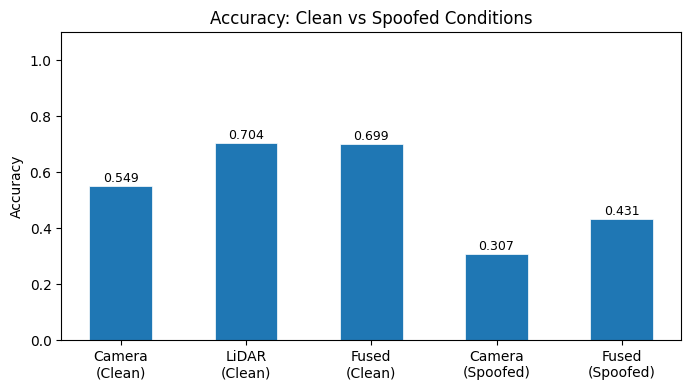

In [ ]:
# Accuracy: All Configurations
fig, ax = plt.subplots(figsize=(8, 4))
configs = ["Camera\n(Clean)", "LiDAR\n(Clean)", "Fused\n(Clean)",
           "Camera\n(Spoofed)", "Fused\n(Spoofed)"]
values  = [acc_cam_norm, acc_lidar_norm, acc_fuse_norm, acc_cam_spoof, acc_fuse_spoof]

bars = ax.bar(configs, values, width=0.5, edgecolor="white", linewidth=0.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{val:.3f}", ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, 1.1)
ax.set_title("Accuracy: Clean vs Spoofed Conditions")
ax.set_ylabel("Accuracy")
plt.show()

In [ ]:
print(f"Total test samples : {len(y_test)}")

cam_preds_clean = clf_cam.predict(cam_test)
cam_preds_spoof = clf_cam.predict(cam_test_spoof)
y_arr = np.array(y_test)

flipped = [i for i in range(len(y_arr))
           if cam_preds_clean[i] == y_arr[i] and cam_preds_spoof[i] != y_arr[i]]

print(f"Total flipped samples after spoofing: {len(flipped)}")

sample_idx = next(
    i for i in range(len(y_arr))
    if cam_preds_clean[i] == y_arr[i] and cam_preds_spoof[i] != y_arr[i]
)

print(f"Sample Index   : {sample_idx}")
print(f"Ground Truth   : {y_arr[sample_idx]}")
print(f"Clean  Pred    : {cam_preds_clean[sample_idx]}")
print(f"Spoofed Pred   : {cam_preds_spoof[sample_idx]}")

Total test samples : 1637
Total flipped samples after spoofing: 590
Sample Index   : 1
Ground Truth   : 2
Clean  Pred    : 2
Spoofed Pred   : 3


### Step 10: Results Summary Table

### 10.1 Interpreting the Table

The table below shows accuracy for each sensor configuration under both conditions. Read it as follows:

- **Clean Acc** column: how well each model performs with no attack
- **Spoofed Acc** column: how well each model performs when the camera is severely corrupted
- LiDAR-only shows `(N/A)` for spoofed accuracy because it doesn't use camera data — it is unaffected

**What to look for:**
- Is the fused model's spoofed accuracy closer to its *clean* accuracy, or closer to the camera-only *spoofed* accuracy?
- Does the fused model still outperform camera-only under the attack?

### 10.2 Understanding Your Results

1. **LiDAR outperforms Camera alone on clean data.** LiDAR captures more reliable spatial information for this navigation task, giving it a ~15% accuracy advantage over camera-only.

2. **Fusion performs comparably to LiDAR alone on clean data.** The fused system (0.6995) closely matches LiDAR-only (0.7043), suggesting camera features add minimal benefit in clean conditions for this dataset.

3. **Camera-only accuracy drops significantly under attack.**  Accuracy falls from 0.5486 to 0.3005 (nearly halved), meaning the model is performing close to random guessing on corrupted features.

4. **Fusion degrades under attack but outperforms camera-only.** The fused model retains partial performance (0.4142) because it still receives clean LiDAR data, but the corrupted camera features actively mislead the model rather than simply contributing nothing.

5. **Fusion does not fully eliminate the spoofing impact.** Notably, the fused system under attack (0.4142) performs worse than clean LiDAR alone (0.7043), meaning the attacked camera drags down an otherwise reliable system.

### 10.3 Why Fusion Doesn't Fully Protect

Early fusion is a **static** weighting strategy: the model learns fixed weights `w_camera` and `w_lidar` during training on clean data. At inference time, if the camera is corrupted, the model still applies its trained camera weights to noisy inputs — it has no mechanism to detect or ignore a compromised sensor. The corrupted camera features don't just add noise; they actively push predictions in wrong directions.

---
### Before you go, think about the following questions:

- **What would happen if you increased `strength` from 4.0 to 10.0?** How would this affect fused vs. camera-only accuracy? Try it!

- **What would a perfect adaptive fusion system do** when it detects that the camera is compromised? How would its behavior differ from the current static fusion model?

- **Is early fusion always better than single-sensor systems in clean conditions?** Can you think of a case where adding a second sensor makes a fused classifier worse?

- **How would you test if the spoofed camera data is detectable?** Design an anomaly detector that could flag when camera readings are compromised.


## ⏱️ Estimated Time: 45–60 minutes